In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
path = "/ceph/atschalz/auto_prep/tabarena/tabarena/seed_df.csv"
seed_df = pd.read_csv(path)
base_df = pd.read_csv("/ceph/atschalz/auto_prep/tabarena/tabarena/base.csv")
comb_results_meta = pd.read_csv("/ceph/atschalz/auto_prep/tabarena/tabarena/comb_results_meta.csv")

seed_df = seed_df[seed_df.fold==0]
base_df = base_df[base_df.fold==0]
comb_results_meta = comb_results_meta[comb_results_meta.fold==0]

In [3]:
comb_results_meta.loc[comb_results_meta.method_subtype=="default"].groupby("ta_name")["Unnamed: 0"].count().sort_values(ascending=True)

ta_name
Mitra_GPU            33
PrepRealTabPFN2.5    49
ExtraTrees           51
CatBoost             51
KNeighbors           51
LightGBM             51
LinearModel          51
ExplainableBM        51
ModernNCA_GPU        51
NeuralNetFastAI      51
PrepLightGBM         51
NeuralNetTorch       51
PrepLinearModel      51
PrepTabM             51
RandomForest         51
RealMLP_GPU          51
RealTabPFN2.5        51
TabDPT_GPU           51
TabICL_GPU           51
TabM                 51
TabPFNv2_GPU         51
XGBoost              51
xRFM_GPU             51
Name: Unnamed: 0, dtype: int64

### Training time

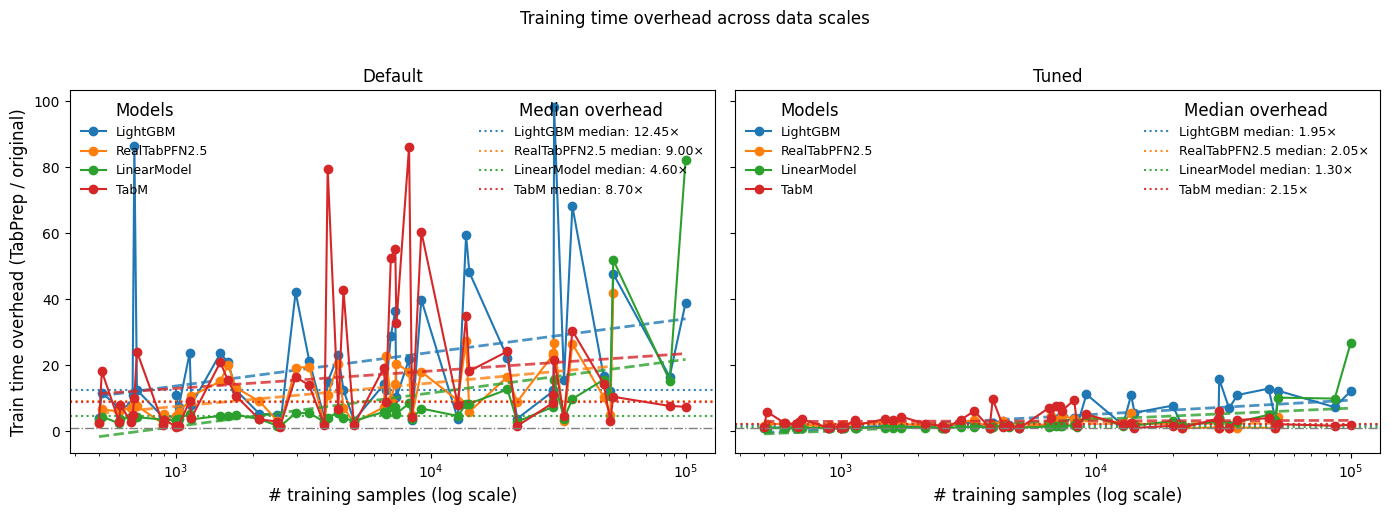

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = comb_results_meta.copy()
df = df[df["method_subtype"].isin(["default", "tuned"])].copy()

model_pairs = {
    "LightGBM": "PrepLightGBM",
    "RealTabPFN2.5": "PrepRealTabPFN2.5",
    "LinearModel": "PrepLinearModel",
    "TabM": "PrepTabM",
}

rows = []

for subtype in ["default", "tuned"]:
    for base_model, prep_model in model_pairs.items():
        base = df[
            (df["ta_name"] == base_model) &
            (df["method_subtype"] == subtype)
        ][["dataset", "time_train_s", "n_samples_train_per_fold"]].copy()

        prep = df[
            (df["ta_name"] == prep_model) &
            (df["method_subtype"] == subtype)
        ][["dataset", "time_train_s"]].copy()

        merged = base.merge(
            prep,
            on="dataset",
            how="inner",
            suffixes=("_base", "_tabprep")
        )

        if merged.empty:
            continue

        merged["time_train_s_tabprep"] = merged["time_train_s_tabprep"] + merged["time_train_s_base"]*0.75

        merged["model"] = base_model
        merged["method_subtype"] = subtype
        merged["train_overhead_rel"] = (
            merged["time_train_s_tabprep"] / merged["time_train_s_base"]
        )

        rows.append(merged)

plot_df = pd.concat(rows, ignore_index=True)

model_order = list(model_pairs.keys())
color_map = {model: f"C{i}" for i, model in enumerate(model_order)}

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, subtype in zip(axes, ["default", "tuned"]):
    sub = plot_df[plot_df["method_subtype"] == subtype].copy()

    curve_handles = []
    median_handles = []

    for model in model_order:
        g = sub[sub["model"] == model].sort_values("n_samples_train_per_fold")
        if g.empty:
            continue

        color = color_map[model]
        median_overhead = g["train_overhead_rel"].median()

        line, = ax.plot(
            g["n_samples_train_per_fold"],
            g["train_overhead_rel"],
            marker="o",
            color=color,
            label=model
        )
        curve_handles.append(line)

        median_line = ax.axhline(
            median_overhead,
            linestyle=":",
            linewidth=1.5,
            alpha=0.9,
            color=color,
            label=f"{model} median: {median_overhead:.2f}×"
        )
        median_handles.append(median_line)

        x = np.log(g["n_samples_train_per_fold"].to_numpy())
        y = g["train_overhead_rel"].to_numpy()   # use "train_overhead_rel" for training time

        mask = np.isfinite(x) & np.isfinite(y)
        x = x[mask]
        y = y[mask]

        if len(x) >= 2:
            slope, intercept = np.polyfit(x, y, 1)

            x_fit = np.linspace(x.min(), x.max(), 200)
            y_fit = slope * x_fit + intercept

            ax.plot(
                np.exp(x_fit),
                y_fit,
                color=color,
                linestyle="--",
                linewidth=2,
                alpha=0.8,
                label=f"{model} trend"
            )

    ax.axhline(1.0, linestyle="-.", color="gray", linewidth=1)
    ax.set_xscale("log")
    ax.set_xlabel("# training samples (log scale)", fontsize=12)
    ax.set_title(subtype.capitalize(), fontsize=12)

    legend1 = ax.legend(
        handles=curve_handles,
        title="Models",
        loc="upper left",
        frameon=False,
        fontsize=9,
        title_fontsize=12
    )
    ax.add_artist(legend1)

    ax.legend(
        handles=median_handles,
        title="Median overhead",
        loc="upper right",
        frameon=False,
        fontsize=9,
        title_fontsize=12
    )

axes[0].set_ylabel("Train time overhead (TabPrep / original)", fontsize=12)



fig.suptitle("Training time overhead across data scales", y=1.02)
plt.tight_layout()
# plt.savefig("/ceph/atschalz/auto_prep/tabarena/tabarena/tabarena/icml2026/figures/train_time_overhead_across_data_scales.pdf")

plt.show()

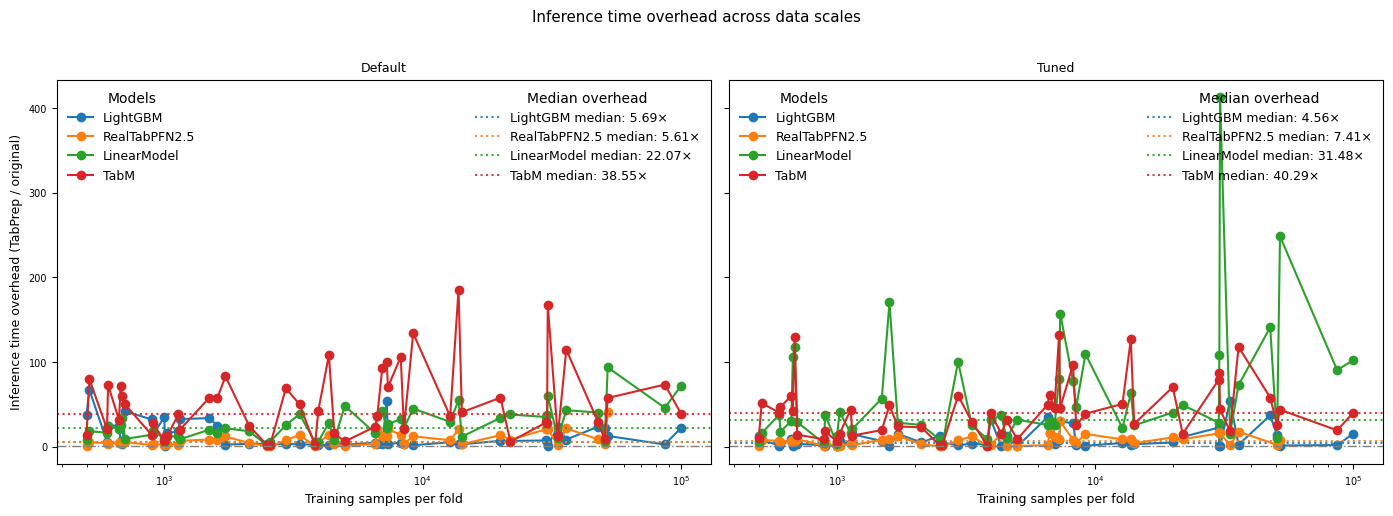

In [ ]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt

# df = comb_results_meta.copy()
# df = df[df["method_subtype"].isin(["default", "tuned"])].copy()

# model_pairs = {
#     "LightGBM": "PrepLightGBM",
#     "RealTabPFN2.5": "PrepRealTabPFN2.5",
#     "LinearModel": "PrepLinearModel",
#     "TabM": "PrepTabM",
# }

# rows = []

# for subtype in ["default", "tuned"]:
#     for base_model, prep_model in model_pairs.items():
#         base = df[
#             (df["ta_name"] == base_model) &
#             (df["method_subtype"] == subtype)
#         ][["dataset", "time_infer_s", "n_samples_train_per_fold"]].copy()

#         prep = df[
#             (df["ta_name"] == prep_model) &
#             (df["method_subtype"] == subtype)
#         ][["dataset", "time_infer_s"]].copy()

#         merged = base.merge(
#             prep,
#             on="dataset",
#             how="inner",
#             suffixes=("_base", "_tabprep")
#         )

#         if merged.empty:
#             continue

#         merged["model"] = base_model
#         merged["method_subtype"] = subtype
#         merged["infer_overhead_rel"] = (
#             merged["time_infer_s_tabprep"] / merged["time_infer_s_base"]
#         )

#         rows.append(merged)

# plot_df = pd.concat(rows, ignore_index=True)

# model_order = list(model_pairs.keys())
# color_map = {model: f"C{i}" for i, model in enumerate(model_order)}

# fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# for ax, subtype in zip(axes, ["default", "tuned"]):
#     sub = plot_df[plot_df["method_subtype"] == subtype].copy()

#     curve_handles = []
#     median_handles = []

#     for model in model_order:
#         g = sub[sub["model"] == model].sort_values("n_samples_train_per_fold")
#         if g.empty:
#             continue

#         color = color_map[model]
#         median_overhead = g["infer_overhead_rel"].median()

#         line, = ax.plot(
#             g["n_samples_train_per_fold"],
#             g["infer_overhead_rel"],
#             marker="o",
#             color=color,
#             label=model
#         )
#         curve_handles.append(line)

#         median_line = ax.axhline(
#             median_overhead,
#             linestyle=":",
#             linewidth=1.5,
#             alpha=0.9,
#             color=color,
#             label=f"{model} median: {median_overhead:.2f}×"
#         )
#         median_handles.append(median_line)

#     ax.axhline(1.0, linestyle="-.", color="gray", linewidth=1)
#     ax.set_xscale("log")
#     ax.set_xlabel("Training samples per fold")
#     ax.set_title(subtype.capitalize())

#     legend1 = ax.legend(
#         handles=curve_handles,
#         title="Models",
#         loc="upper left",
#         frameon=False,
#         fontsize=9,
#         title_fontsize=10
#     )
#     ax.add_artist(legend1)

#     ax.legend(
#         handles=median_handles,
#         title="Median overhead",
#         loc="upper right",
#         frameon=False,
#         fontsize=9,
#         title_fontsize=10
#     )

# axes[0].set_ylabel("Inference time overhead (TabPrep / original)")

# fig.suptitle("Inference time overhead across data scales", y=1.02)
# plt.tight_layout()
# plt.show()

### Random Seed Sensitivity

In [58]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from matplotlib.lines import Line2D

def _plot_kde(ax, values, color="k", lw=1.0, alpha=1.0, xmin=None, xmax=None, density_tol=1e-4):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if len(values) < 2:
        return

    if np.allclose(values, values[0]):
        ax.axvline(values[0], color=color, lw=lw, alpha=alpha)
        return

    if xmin is None:
        xmin = values.min()
    if xmax is None:
        xmax = values.max()

    xs = np.linspace(xmin, xmax, 400)
    ys = gaussian_kde(values)(xs)

    mask = ys > density_tol * ys.max()
    if not np.any(mask):
        return

    start = np.argmax(mask)
    end = len(mask) - np.argmax(mask[::-1])

    ax.plot(xs[start:end], ys[start:end], color=color, lw=lw, alpha=alpha)


def plot_seed_kdes_fullpage(seed_df, base_df):
    datasets = [
        'airfoil_self_noise',
        'Amazon_employee_access',
        'anneal',
        'Another-Dataset-on-used-Fiat-500',
        'APSFailure',
        'bank-marketing',
        'Bank_Customer_Churn',
        'Bioresponse',
        'blood-transfusion-service-center',
        'churn',
        'coil2000_insurance_policies',
        'concrete_compressive_strength',
        'credit-g',
        'credit_card_clients_default',
        'customer_satisfaction_in_airline',
        'diabetes',
        'Diabetes130US',
        'diamonds',
        'E-CommereShippingData',
        'Fitness_Club',
    ]

    plt.rcParams.update({
        "font.size": 18,
        "axes.titlesize": 18,
        "axes.labelsize": 18,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 18,
        "lines.linewidth": 1.2,
    })

    ncols = 5
    nrows = 4

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(24, 15),
        sharey=False
    )
    axes = axes.flatten()

    base_color = "tab:blue"
    seed_color = "tab:red"

    for i, dat in enumerate(datasets):
        ax = axes[i]

        seed_df_dat = seed_df[seed_df["dataset"] == dat]
        base_df_dat = base_df[base_df["dataset"] == dat]

        seed_col = (
            "CategoricalInteractionFeatureGenerator"
            if dat == "Amazon_employee_access"
            else "RandomSubsetTAFC"
        )

        all_vals = []
        base_vals = base_df_dat["metric_error"].dropna().to_numpy()
        if len(base_vals) > 1:
            all_vals.append(base_vals)

        seed_groups = []
        for seed in seed_df_dat[seed_col].dropna().unique():
            vals = seed_df_dat.loc[
                seed_df_dat[seed_col] == seed, "metric_error"
            ].dropna().to_numpy()
            if len(vals) > 1:
                seed_groups.append((seed, vals))
                all_vals.append(vals)

        if not all_vals:
            ax.set_visible(False)
            continue

        all_concat = np.concatenate(all_vals)
        xmin, xmax = all_concat.min(), all_concat.max()

        if len(base_vals) > 1:
            _plot_kde(
                ax, base_vals,
                color=base_color,
                lw=2.6,
                alpha=1.0,
                xmin=xmin,
                xmax=xmax,
                density_tol=1e-3,
            )

        for _, vals in seed_groups:
            _plot_kde(
                ax, vals,
                color=seed_color,
                lw=1.3,
                alpha=0.28,
                xmin=xmin,
                xmax=xmax,
                density_tol=1e-3,
            )

        ax.set_title(dat, pad=10)
        ax.set_xlabel("Metric Error")

        if i % ncols == 0:
            ax.set_ylabel("Density")
        else:
            ax.set_ylabel("")

        ax.tick_params(length=4, width=1)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        # Slight breathing room around the plotted density
        ax.margins(x=0.02, y=0.08)

    # Hide any unused panels
    for j in range(len(datasets), len(axes)):
        axes[j].set_visible(False)

    handles = [
        Line2D([0], [0], color=base_color, lw=2.6, label="Base"),
        Line2D([0], [0], color=seed_color, lw=1.8, alpha=0.95, label="TabPrep Seeds"),
    ]

    fig.legend(
        handles=handles,
        loc="upper center",
        ncol=2,
        frameon=False,
        bbox_to_anchor=(0.5, 0.985),
        handlelength=2.8,
        columnspacing=2.0,
    )

    fig.subplots_adjust(
        left=0.06,
        right=0.995,
        bottom=0.07,
        top=0.90,
        wspace=0.28,
        hspace=0.65,
    )

    fig.savefig(
        "/ceph/atschalz/auto_prep/tabarena/tabarena/tabarena/icml2026/figures/seed_sensitivity_fullpage.pdf",
        bbox_inches="tight", dpi=300, transparent=True
    )
    plt.show()

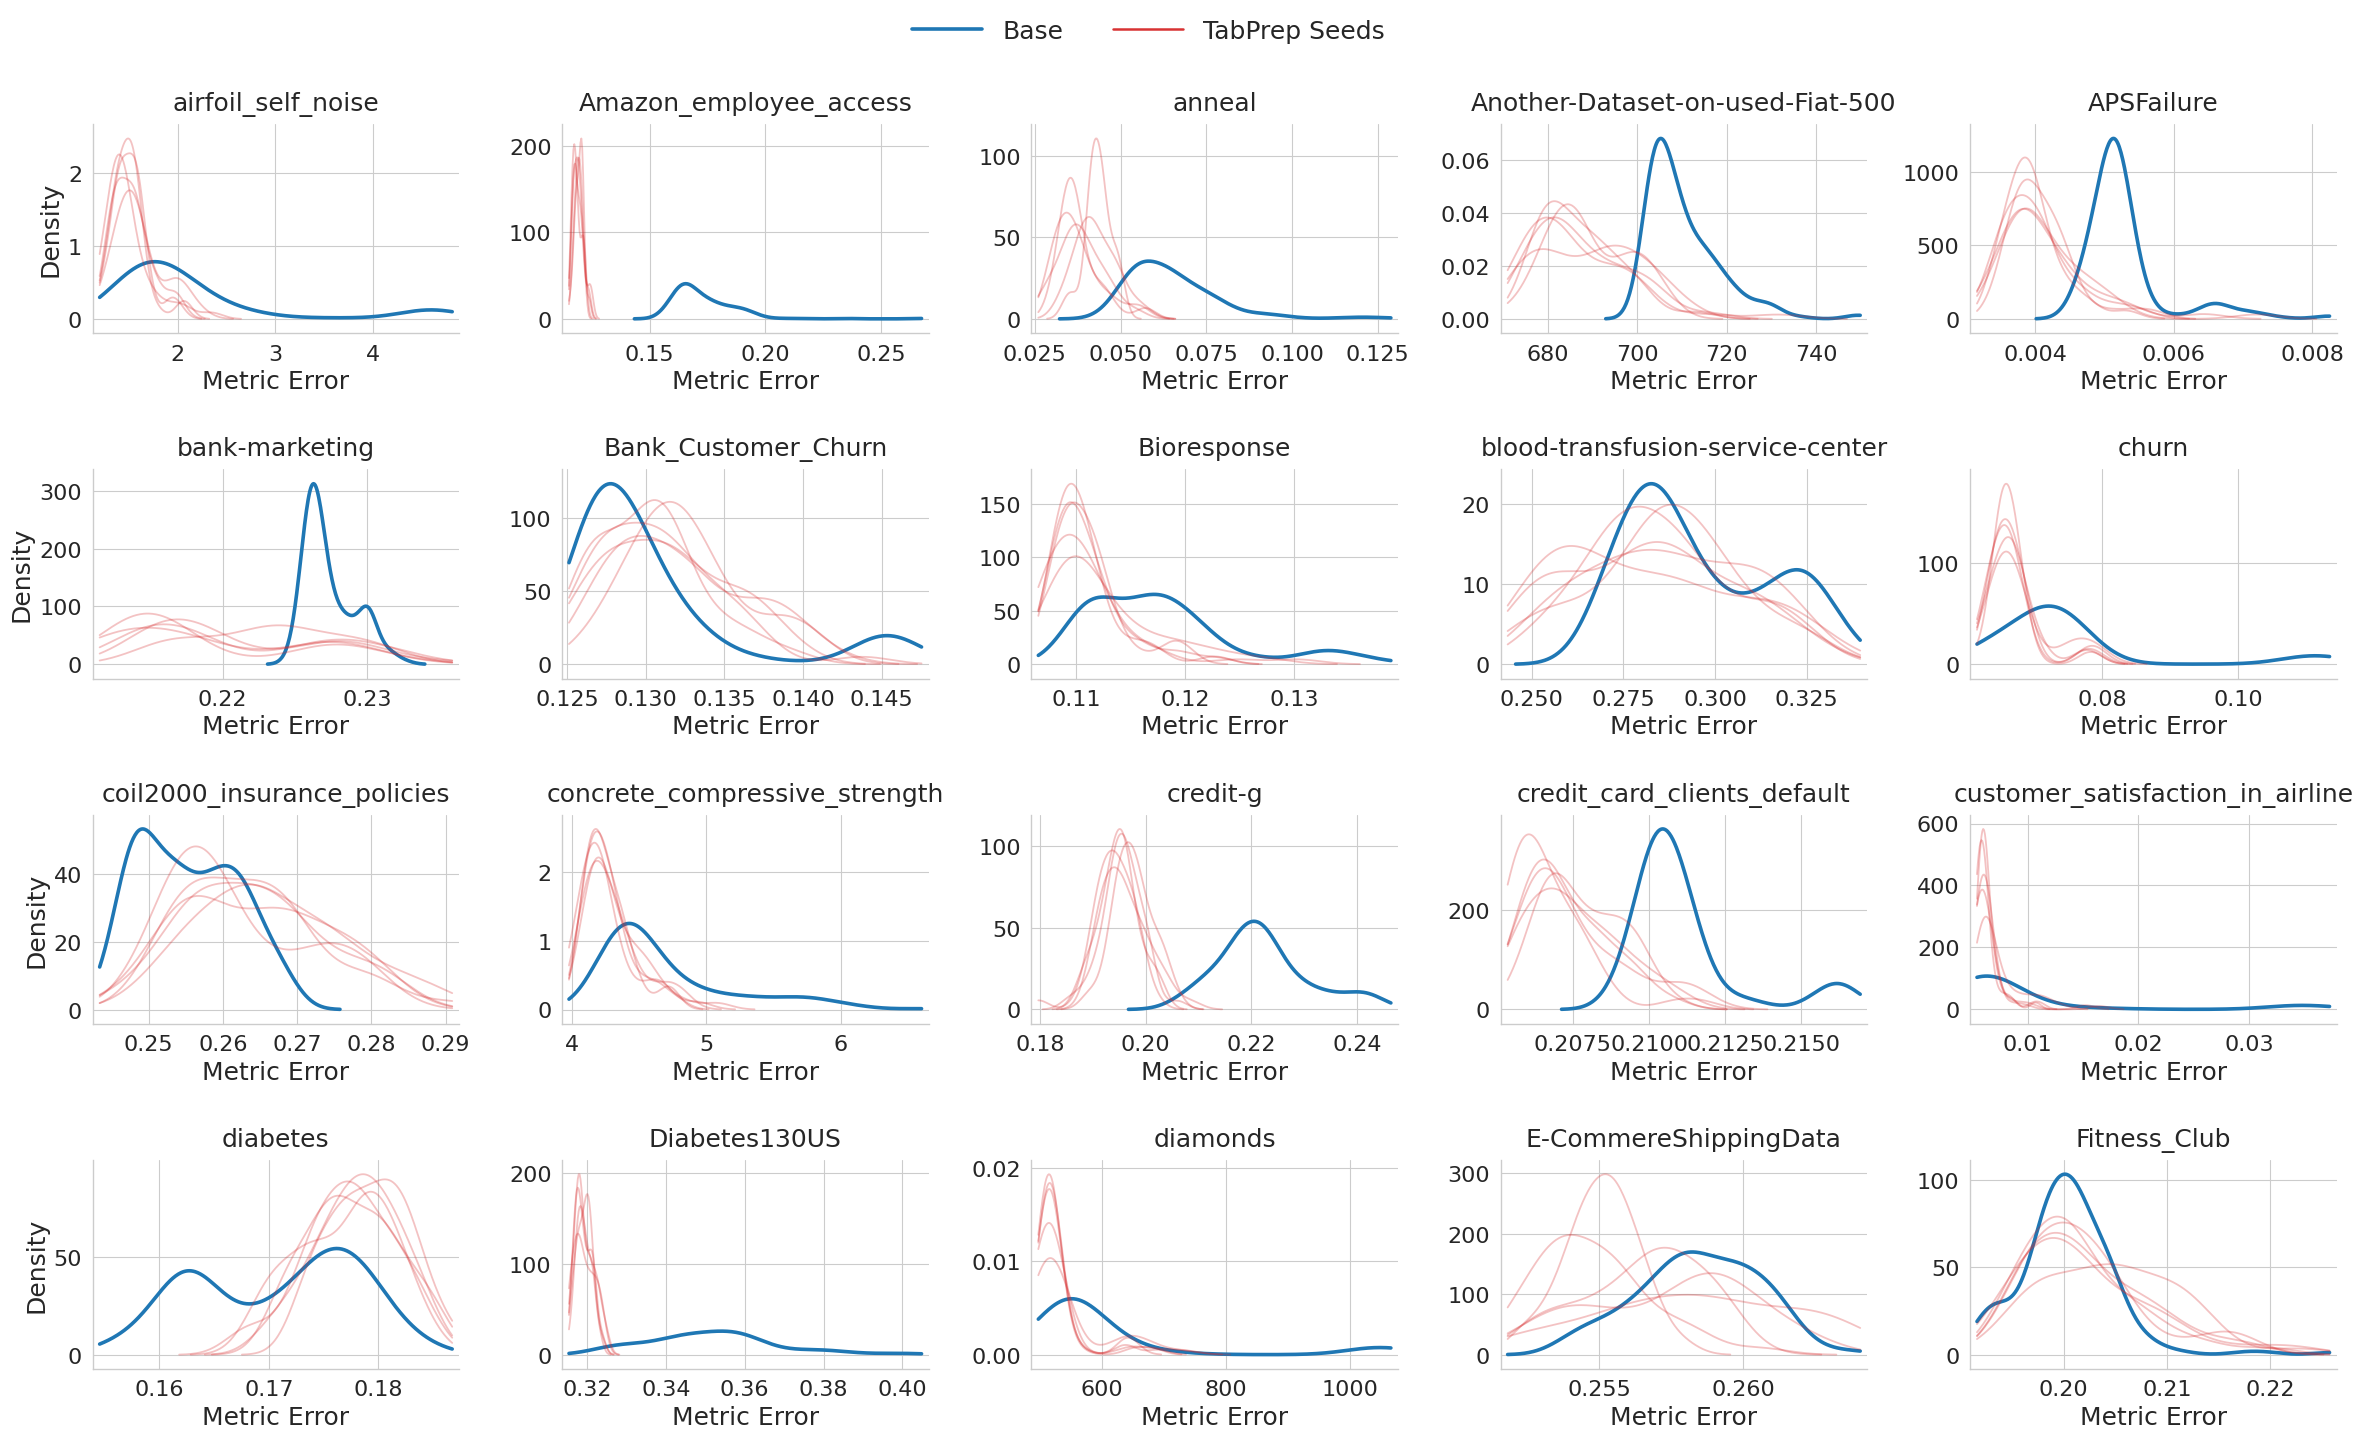

In [59]:
plot_seed_kdes_fullpage(seed_df, base_df)

In [45]:
sorted(seed_df.dataset.str.lower().unique())

['airfoil_self_noise',
 'amazon_employee_access',
 'anneal',
 'another-dataset-on-used-fiat-500',
 'apsfailure',
 'bank-marketing',
 'bank_customer_churn',
 'bioresponse',
 'blood-transfusion-service-center',
 'churn',
 'coil2000_insurance_policies',
 'concrete_compressive_strength',
 'credit-g',
 'credit_card_clients_default',
 'customer_satisfaction_in_airline',
 'diabetes',
 'diabetes130us',
 'diamonds',
 'e-commereshippingdata',
 'fitness_club',
 'food_delivery_time',
 'givemesomecredit',
 'hazelnut-spread-contaminant-detection',
 'healthcare_insurance_expenses',
 'heloc',
 'hiva_agnostic',
 'houses',
 'hr_analytics_job_change_of_data_scientists',
 'in_vehicle_coupon_recommendation',
 'is-this-a-good-customer',
 'jm1',
 'kddcup09_appetency',
 'marketing_campaign',
 'maternal_health_risk',
 'miami_housing',
 'mic',
 'naticusdroid',
 'online_shoppers_intention',
 'physiochemical_protein',
 'polish_companies_bankruptcy',
 'qsar-biodeg',
 'qsar-tid-11',
 'qsar_fish_toxicity',
 'sdss17'

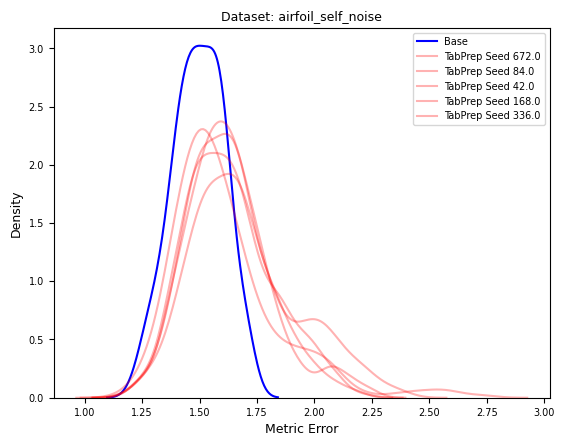

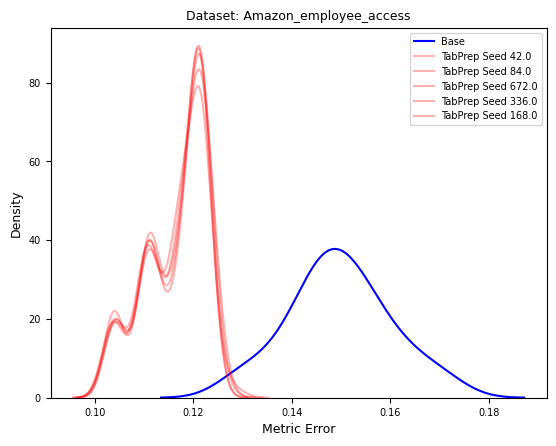

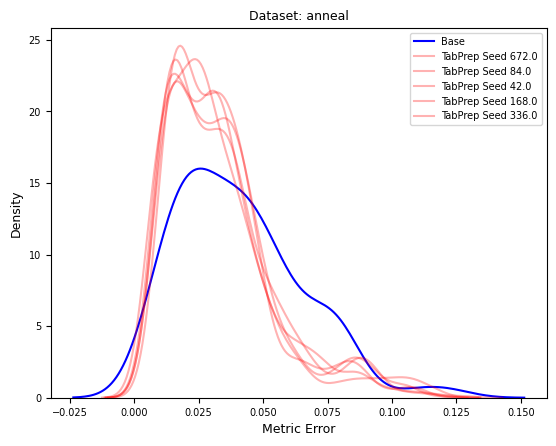

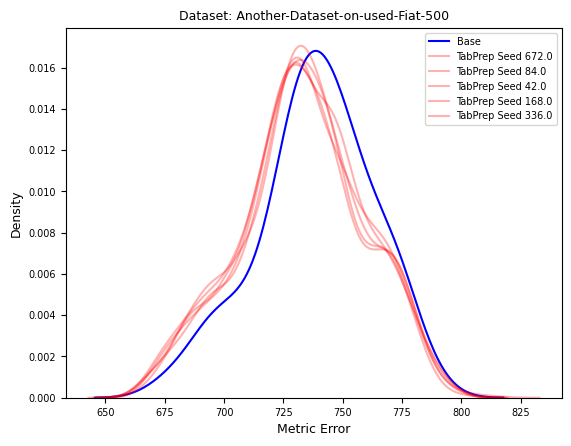

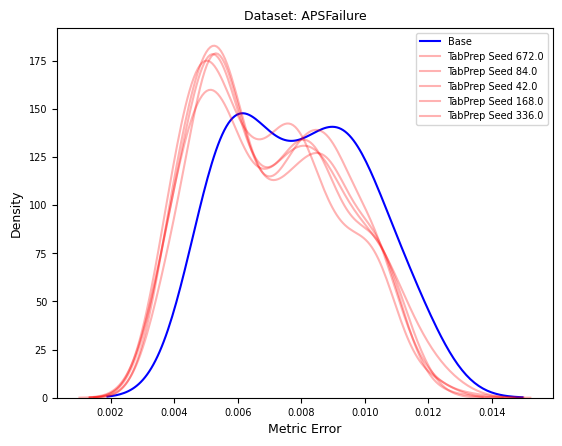

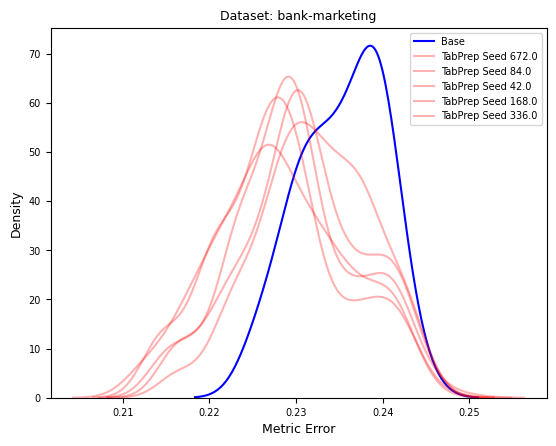

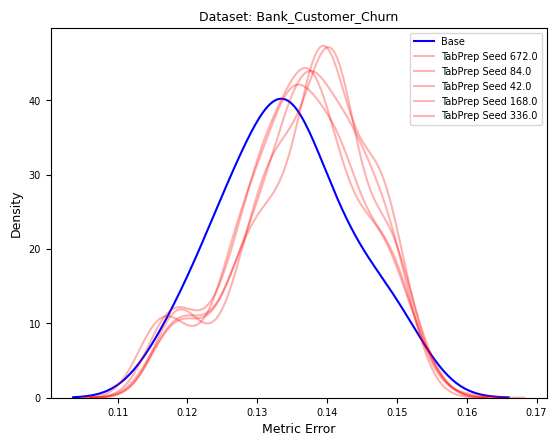

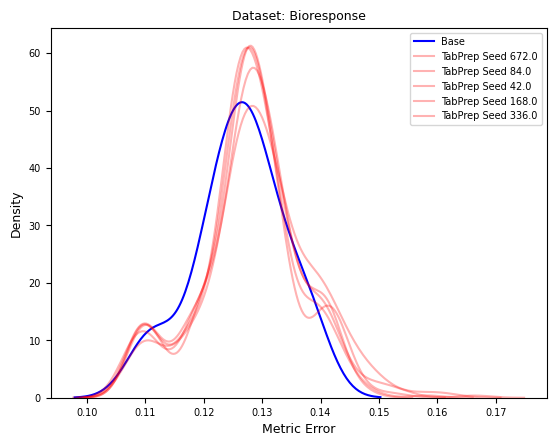

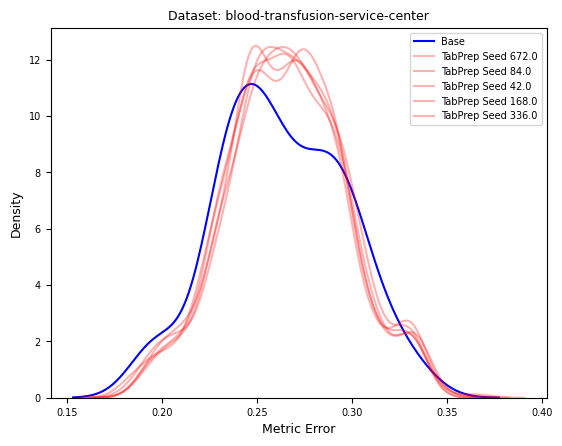

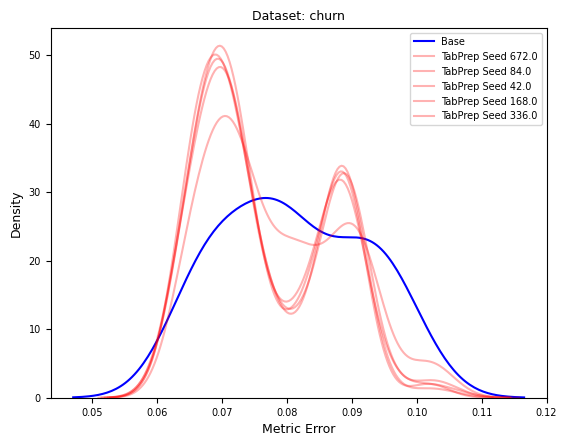

In [ ]:
alphabetical_10 = [
    'airfoil_self_noise',
    'Amazon_employee_access',
    'anneal',
    'Another-Dataset-on-used-Fiat-500',
    'APSFailure',
    'bank-marketing',
    'Bank_Customer_Churn',
    'Bioresponse',
    'blood-transfusion-service-center',
    'churn',
]
for num, dat in enumerate(alphabetical_10):
    seed_df_dat = seed_df[seed_df["dataset"] == dat]
    base_df_dat = base_df[base_df["dataset"] == dat]
    sns.kdeplot(base_df_dat["metric_error"], label="Base", color="blue")
    if dat in ["Amazon_employee_access"]:
        for seed in seed_df_dat["CategoricalInteractionFeatureGenerator"].unique():
             sns.kdeplot(seed_df_dat[seed_df_dat["CategoricalInteractionFeatureGenerator"] == seed]["metric_error"], label=f"TabPrep Seed {seed}", color="red", alpha=0.3)
    else:
        for seed in seed_df_dat["RandomSubsetTAFC"].unique():
             sns.kdeplot(seed_df_dat[seed_df_dat["RandomSubsetTAFC"] == seed]["metric_error"], label=f"TabPrep Seed {seed}", color="red", alpha=0.3)
    plt.legend()
    plt.title(f"Dataset: {dat}")
    plt.xlabel("Metric Error")
    plt.ylabel("Density")
    plt.show()
    if num >10:
        break

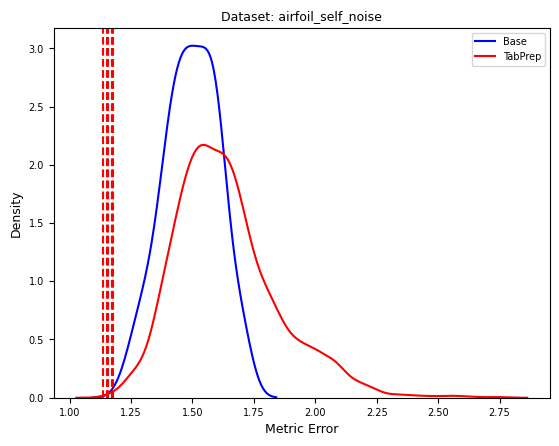

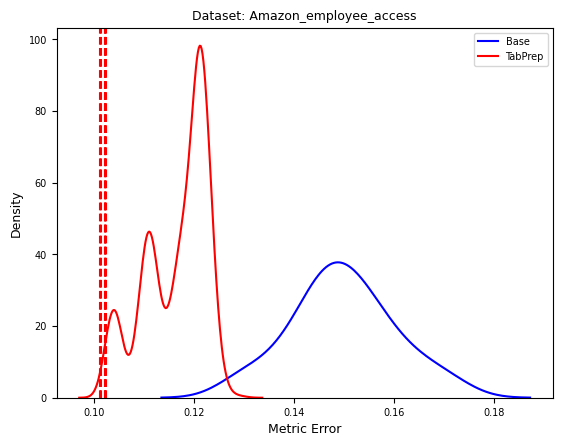

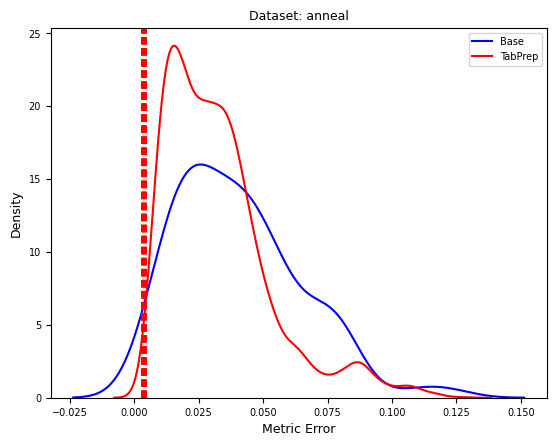

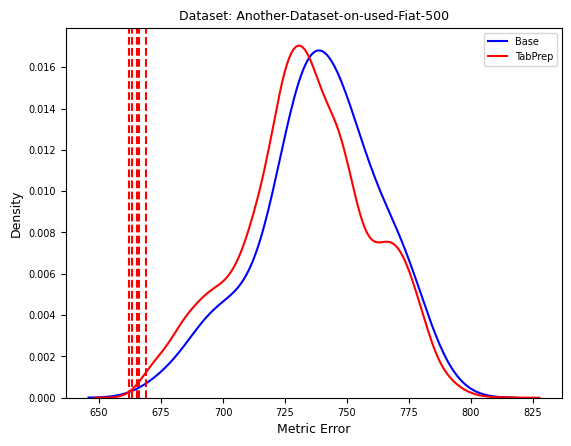

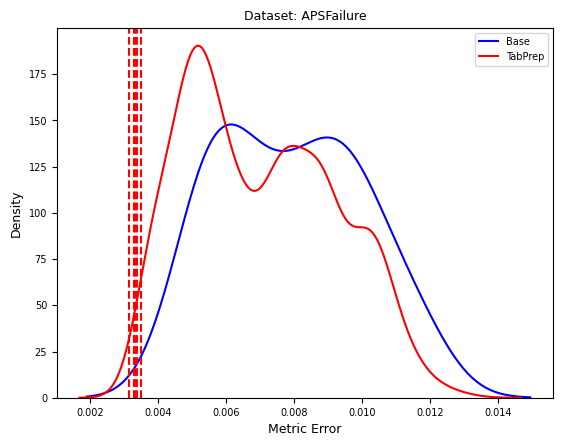

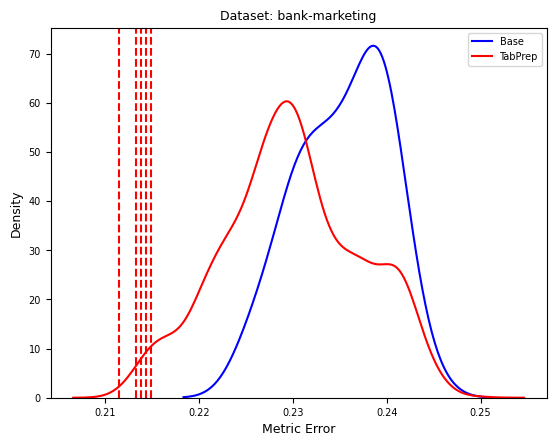

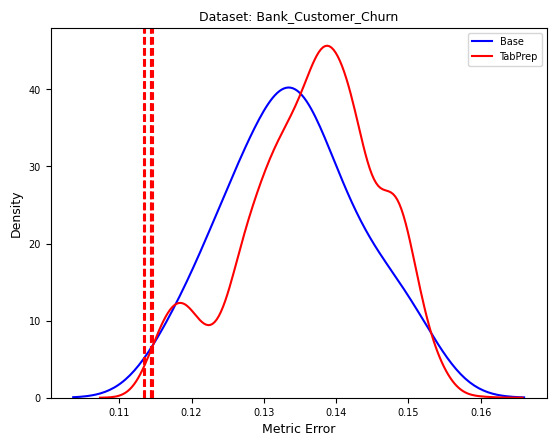

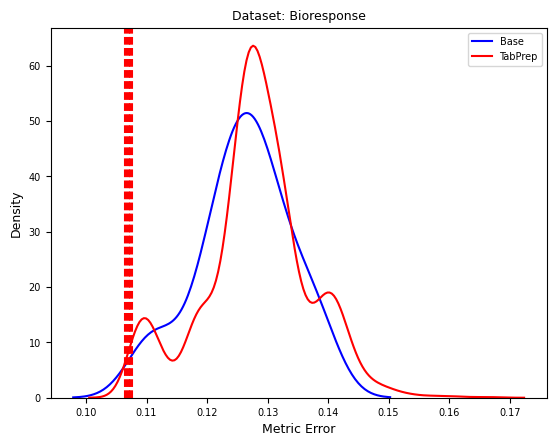

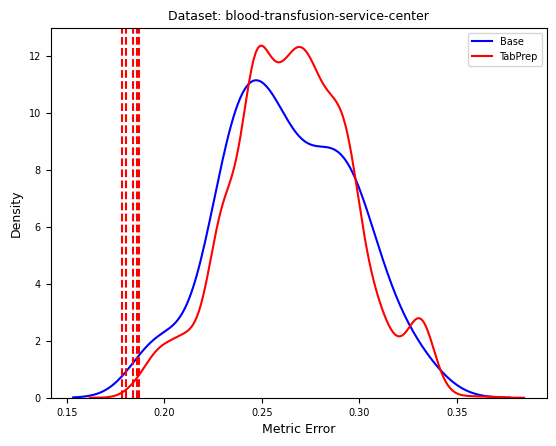

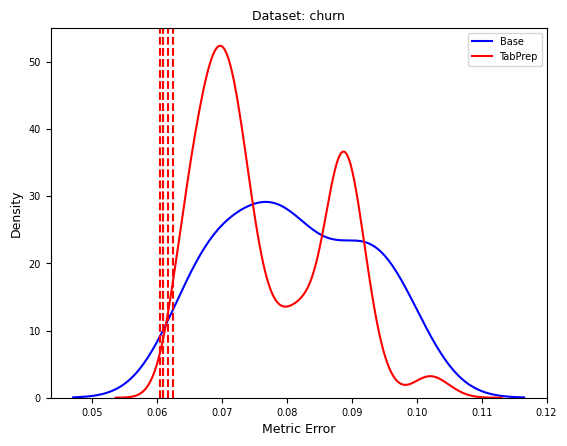

In [29]:
alphabetical_10 = [
    'airfoil_self_noise',
    'Amazon_employee_access',
    'anneal',
    'Another-Dataset-on-used-Fiat-500',
    'APSFailure',
    'bank-marketing',
    'Bank_Customer_Churn',
    'Bioresponse',
    'blood-transfusion-service-center',
    'churn',
]
for num, dat in enumerate(alphabetical_10):
    seed_df_dat = seed_df[seed_df["dataset"] == dat]
    base_df_dat = base_df[base_df["dataset"] == dat]
    sns.kdeplot(base_df_dat["metric_error"], label="Base", color="blue")
    sns.kdeplot(seed_df_dat["metric_error"], label="TabPrep", color="red")
    plt.legend()
    if dat in ["APSFailure", "Amazon_employee_access"]:
        for mean_value in seed_df_dat.groupby("CategoricalInteractionFeatureGenerator")["metric_error"].min():
             plt.axvline(mean_value, color="red", linestyle="--")
    else:
        for mean_value in seed_df_dat.groupby("RandomSubsetTAFC")["metric_error"].min():
            plt.axvline(mean_value, color="red", linestyle="--")
    plt.title(f"Dataset: {dat}")
    plt.xlabel("Metric Error")
    plt.ylabel("Density")
    plt.show()
    if num >10:
        break

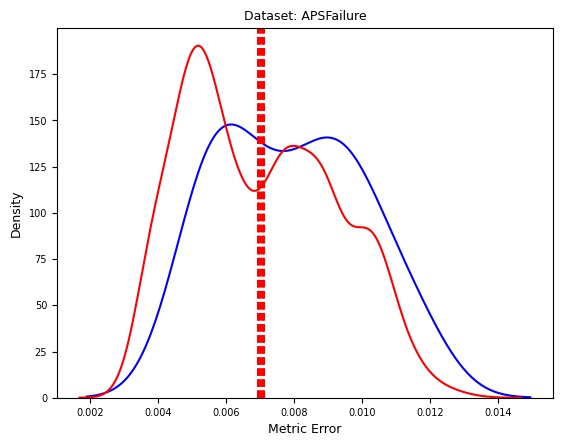

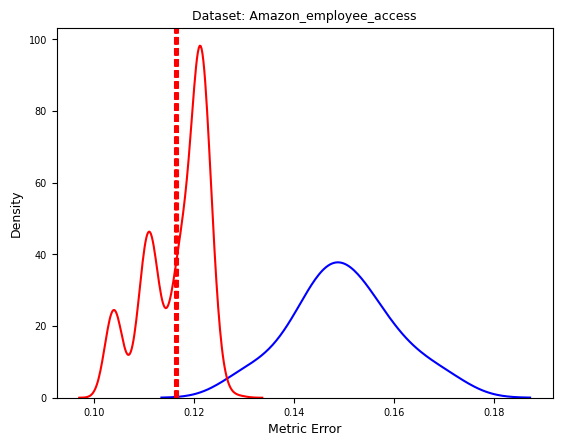

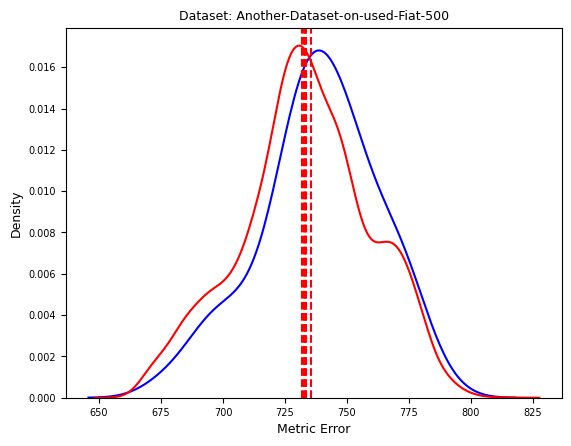

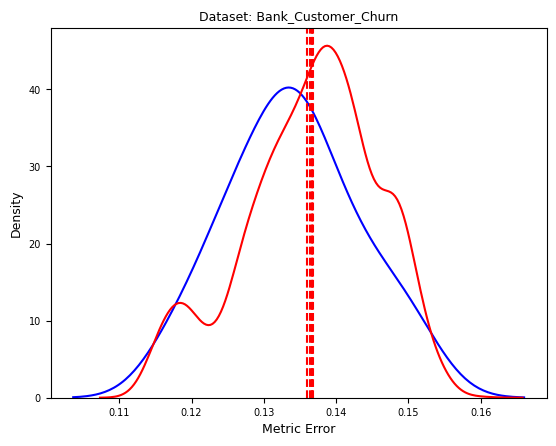

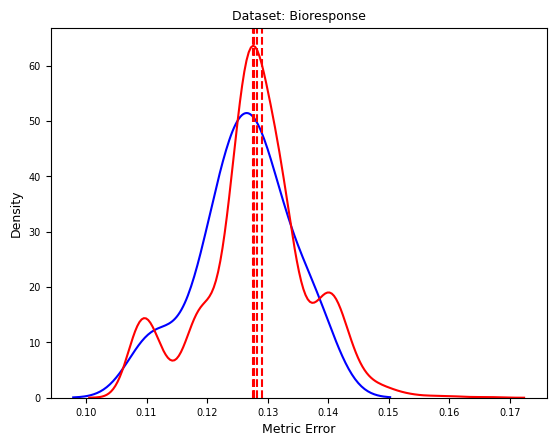

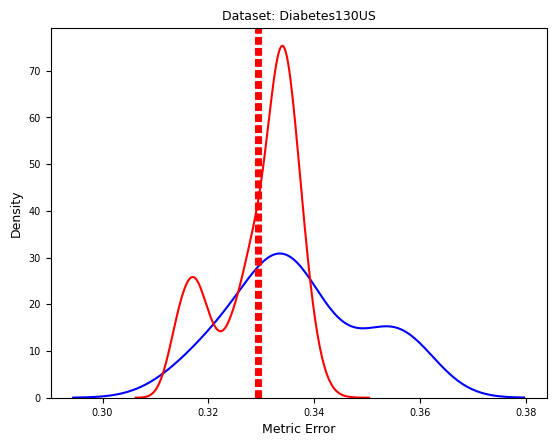

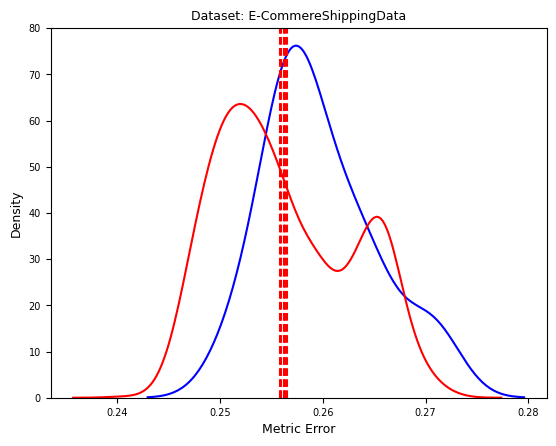

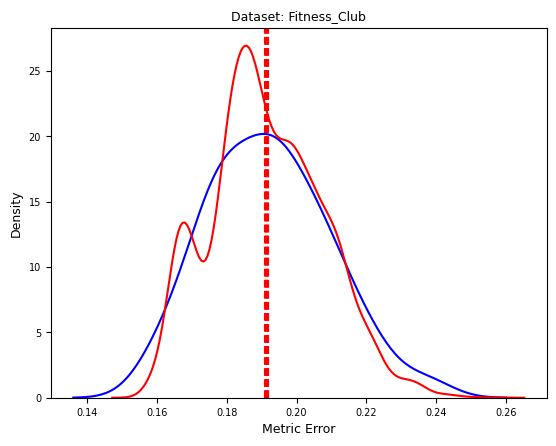

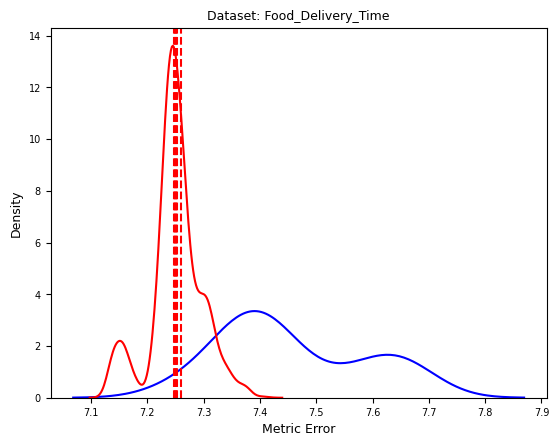

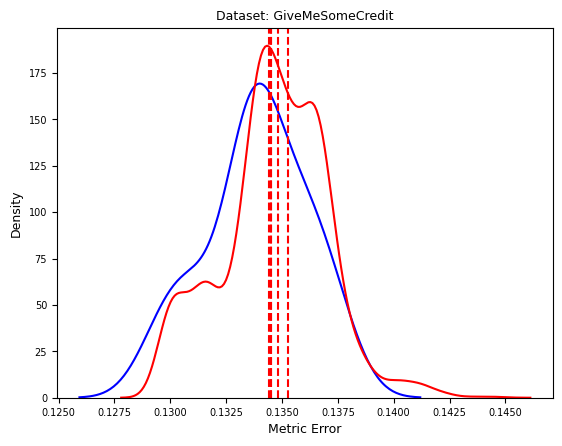

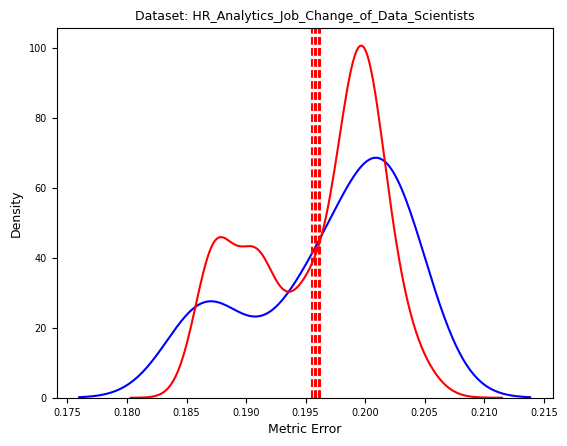

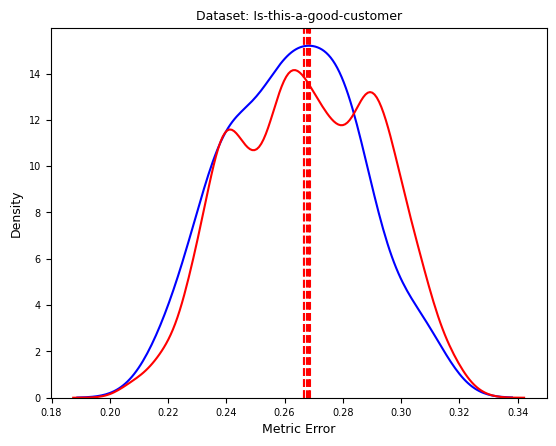

In [11]:
for num, dat in enumerate(seed_df["dataset"].unique()):
    seed_df_dat = seed_df[seed_df["dataset"] == dat]
    base_df_dat = base_df[base_df["dataset"] == dat]
    sns.kdeplot(base_df_dat["metric_error"], label="Base", color="blue")
    sns.kdeplot(seed_df_dat["metric_error"], label="TabPrep", color="red")
    for mean_value in seed_df_dat.groupby("CategoricalInteractionFeatureGenerator")["metric_error"].mean():
        plt.axvline(mean_value, color="red", linestyle="--")
    plt.title(f"Dataset: {dat}")
    plt.xlabel("Metric Error")
    plt.ylabel("Density")
    plt.show()
    if num >10:
        break

In [10]:
seed_df.columns

Index(['Unnamed: 0', 'dataset', 'fold', 'method', 'metric_error',
       'time_train_s', 'time_infer_s', 'metric', 'problem_type',
       'metric_error_val', 'method_type', 'config_type', 'ta_name', 'ta_suite',
       'GroupByFeatureGenerator', 'RandomSubsetTAFC',
       'ArithmeticFeatureGenerator', 'CategoricalInteractionFeatureGenerator',
       'OOFTargetEncodingFeatureGenerator', 'SpearmanFeatureSelector',
       'metric_score_q25_to_best'],
      dtype='object')